In [1]:
import zodiax as zdx
from jax import numpy as np, scipy as scp

class Normal(zdx.Base):
    """Basic class for modelling a normal distribution"""
    mean      : np.ndarray
    scale     : np.ndarray
    amplitude : np.ndarray


    def __init__(self, mean, scale, amplitude):
        """Constructor for the Normal class"""
        self.mean      = np.asarray(mean,      dtype=float)
        self.scale     = np.asarray(scale,     dtype=float)
        self.amplitude = np.asarray(amplitude, dtype=float)


    def model(self, width=10):
        """Evaluates the normal distribution"""
        xs = np.linspace(-width, width, 128)
        return self.amplitude * scp.stats.norm.pdf(xs, self.mean, self.scale)

In [2]:
class NormalSet(zdx.Base):
    """Basic class for modelling a set of normal distributions"""
    normals : dict
    width   : np.ndarray


    def __init__(self, means, scales, amplitude, names, width=10):
        """Constructor for the NormalSet class"""
        normals = {}
        for i in range(len(names)):
            normals[names[i]] = Normal(means[i], scales[i], amplitude[i])
        self.normals = normals
        self.width = np.asarray(width, dtype=float)


    def __getattr__(self, key):
        """Allows us to access the individual normals by their dictionary key"""
        if key in self.normals.keys():
            return self.normals[key]
        else:
            raise AttributeError(f"{key} not in {self.normals.keys()}")


    def model(self):
        """Evaluates the set of normal distributions"""
        return np.array([normal.model(self.width) 
            for normal in self.normals.values()]).sum(0)


sources = NormalSet([-1., 2.], [1., 2.], [2., 4.], ['alpha', 'beta'])


In [3]:
import jax.random as jr
import matplotlib.pyplot as plt

# Make some data by adding some noise
key = jr.PRNGKey(0)
true_signal = sources.model()
data = true_signal + jr.normal(key, sources.model().shape)/50

# Create a model to initialise
initial_model = NormalSet([-3., 3.], [1., 1.], [2.5, 2.5], ['alpha', 'beta'])

In [4]:
# Now lets construct a loss function
opt_parameters = [
    'alpha.mean', 'alpha.scale', 'alpha.amplitude',
    'beta.mean', 'beta.scale', 'beta.amplitude'
    ]
@zdx.filter_jit
@zdx.filter_value_and_grad(opt_parameters)
def loss_fn(model, data):
    return np.square(model.model() - data).sum()

# Evaluate loss function once Compile to XLA
model = initial_model
loss, grads = loss_fn(model, data)


In [5]:
import optax

# Get optax objcets
model = initial_model
optimiser, state = zdx.get_optimiser(model, opt_parameters, optax.adam(1e-1))

losses = []
for i in range(200):
    loss, grads = loss_fn(model, data)
    step, state = optimiser.update(grads, state)
    model = zdx.apply_updates(model, step)
    losses.append(loss)

In [12]:
# Define the paramters we want to marginalise over
parameters = ['alpha.mean',      'beta.mean', 
              'alpha.scale',     'beta.scale', 
              'alpha.amplitude', 'beta.amplitude']

# Get the covariance matrix
covariance_matrix = zdx.covariance_matrix(model, parameters,
    zdx.chi2_loglike, data, noise=1/50)
deviations = np.abs(np.diag(covariance_matrix))**0.5

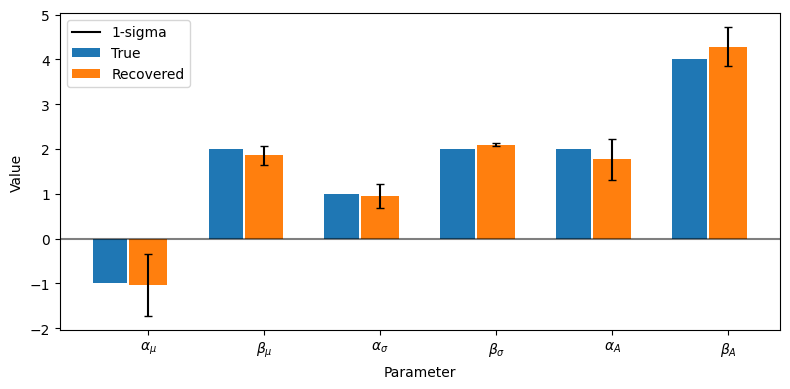

In [14]:
true_values = sources.get(parameters)
recoverd_parameters = model.get(parameters)

formatted = [r"$\alpha_\mu$",    r"$\beta_\mu$",
             r"$\alpha_\sigma$", r"$\beta_\sigma$",
             r"$\alpha_A$",      r"$\beta_A$"]

plt.figure(figsize=(8, 4))
xs = np.arange(len(parameters))
plt.bar(xs, true_values, tick_label=formatted, width=0.3, label='True')
plt.bar(xs+0.33, recoverd_parameters, tick_label=formatted, yerr=deviations,
    width=0.33, label='Recovered', capsize=3)
plt.plot([], c='k', label='1-sigma')
plt.axhline(0, color="k", alpha=0.5)
plt.legend(loc=2)
plt.xlabel("Parameter")
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("fisher_fit")
plt.show()

In [23]:
import numpyro as npy
import numpyro.distributions as dist
import chainconsumer as cc

def sampling_fn(data, model):
    paths = ["alpha.mean",      "beta.mean", 
             "alpha.scale",     "beta.scale",
             "alpha.amplitude", "beta.amplitude"]

    # Define priors
    values = [npy.sample(r"\alpha_\mu",    dist.Normal(0, 5)), 
              npy.sample(r"\beta_\mu",     dist.Normal(0, 5)),
              npy.sample(r"\alpha_\sigma", dist.HalfNormal(5)), 
              npy.sample(r"\beta_\sigma",  dist.HalfNormal(5)),
              npy.sample(r"\alpha_A",      dist.Normal(0, 5)), 
              npy.sample(r"\beta_A",       dist.Normal(0, 5))]

    # Sample from the posterior distribution
    with npy.plate("data", len(data)):
        model_sampler = dist.Normal(
            model.set(paths, values).model()
            )
        return npy.sample("Sampler", model_sampler, obs=data)

In [5]:
# Using the model above, we can now sample from the posterior distribution
# using the No U-Turn Sampler (NUTS).
sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=5000,
    num_samples=5000,
)
%time sampler.run(jr.PRNGKey(0), data, model)

sample: 100%|██████████| 10000/10000 [00:02<00:00, 3947.86it/s, 31 steps of size 1.67e-01. acc. prob=0.92]


CPU times: user 3.41 s, sys: 115 ms, total: 3.52 s
Wall time: 3.52 s


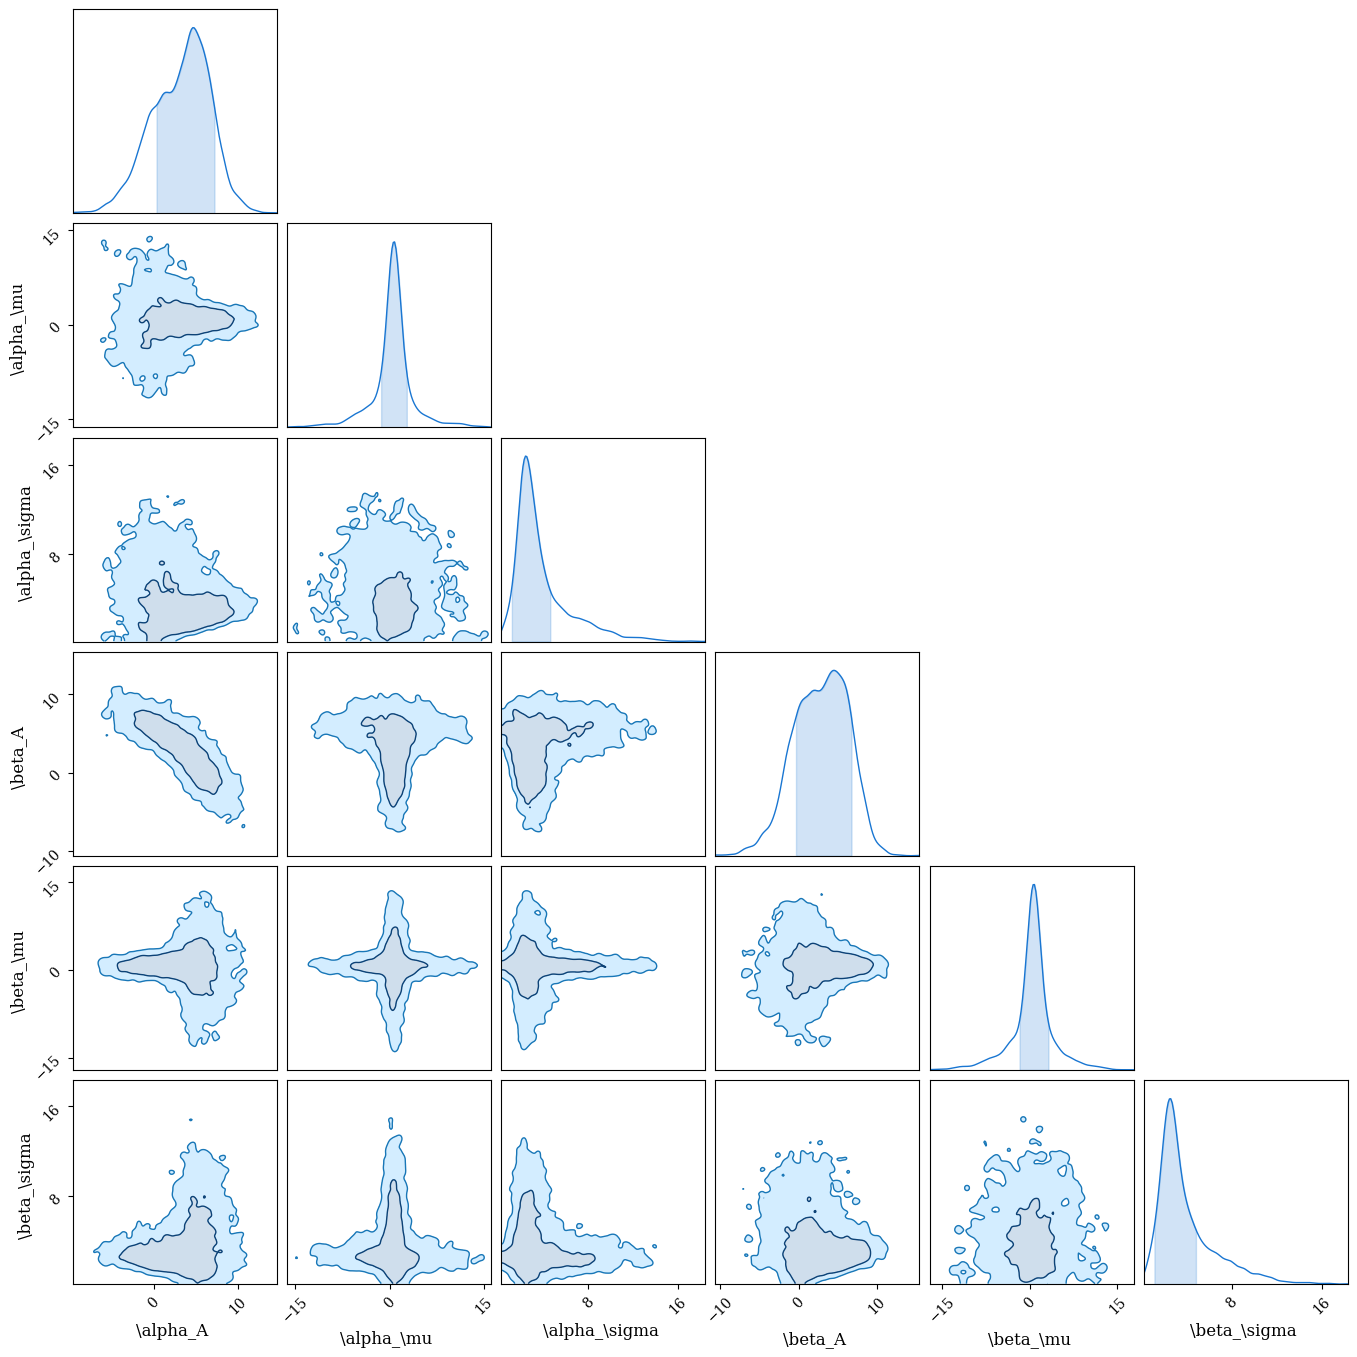

In [6]:
chain = cc.ChainConsumer()
chain.add_chain(sampler.get_samples())
chain.configure(
    serif=True, shade=True, bar_shade=True, shade_alpha=0.2, spacing=1.0, max_ticks=3
)

fig = chain.plotter.plot()
fig.set_size_inches((15, 15))

In [7]:
model

NormalSet(
  normals={
    'alpha':
    Normal(mean=f32[], scale=f32[], amplitude=f32[]),
    'beta':
    Normal(mean=f32[], scale=f32[], amplitude=f32[])
  },
  width=f32[]
)